# דוח ביצועי מפעילים שבועי — 24–30 במאי 2026 (שבוע 22)

השוואת אי-ביצוע נסיעות בין 8 מפעילי תח"צ, מבוססת על Open Bus Stride API (נסיעות מתוכננות מול נסיעות שהותאמו ל-SIRI בזמן אמת).

**הערות מתודולוגיות חשובות (נבדקו מול ה-API):**
1. **מיפוי המפעילים אומת מול ה-API** — מספרי ה-`operator_ref` ברשימה המקורית היו שגויים ברובם (ראו טבלת המיפוי למטה).
2. **"בוצע" = נסיעה שהותאמה לנסיעת SIRI בזמן אמת** (`actual_start_time` אינו NULL ב-`/rides_execution/list`). נסיעה ללא התאמה נספרת כ**אי-ביצוע** — זו המתודולוגיה המקובלת ב-open-bus ל"נסיעות חסרות".
3. **אי אפשר לחשב איחורי יציאה/הגעה (קנסות טבלאות 3–4) מה-API הזה** — בשדה `actual_start_time` הזמן בפועל זהה תמיד לזמן המתוכנן (אינו זמן SIRI נצפה), וזמני העצירה ב-`siri_ride_stops` דלילים/ריקים ברובם. לכן חושב **רק קנס אי-ביצוע (טבלאות 1–2)**, ושיעור האיחור מסומן N/A.
4. התאריכים מקובצים לפי **זמן ישראל** (Asia/Jerusalem). 24/05 = יום ראשון, ולכן הירידה בנסיעות ב-29/05 (שישי) וב-30/05 (שבת) משקפת את **תבנית השבת הרגילה**, לא חוסר בנתונים.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams['axes.unicode_minus'] = False
DATA_DIR = Path('../data')

def heb(s):
    """Reverse Hebrew label for correct RTL rendering in matplotlib."""
    return str(s)[::-1]

# מיפוי operator_ref -> שם, כפי שאומת מול ה-API ב-2026-05-30
OPERATORS = {18: 'קווים', 15: 'מטרופולין', 3: 'אגד', 5: 'דן',
             34: 'תנופה', 16: 'סופרבוס', 25: 'אלקטרה אפיקים', 4: 'אלקטרה אפיקים תחבורה'}
print('מפעילים בדוח:', len(OPERATORS))

מפעילים בדוח: 8


## אימות מיפוי המפעילים (בדיקת שפיות א')
ה-`operator_ref` שסופקו בבקשה אומתו מול שדה `agency_name` ב-API. רק מפעיל אחד (25) היה נכון.

In [2]:
mapping_check = pd.DataFrame([
    ('קווים (Kavim)',           3, 'אגד',                  18),
    ('מטרופולין (Metropoline)', 14, 'נתיב אקספרס',          15),
    ('אגד (Egged)',             5, 'דן',                    3),
    ('דן (Dan)',                7, 'נסיעות ותיירות',         5),
    ('תנופה (Tnufa)',          32, 'דן באר שבע',            34),
    ('סופרבוס (Superbus)',     15, 'מטרופולין',             16),
    ('אלקטרה אפיקים',          25, 'אלקטרה אפיקים',         25),
    ('אפיקים (≈תחבורה)',       25, 'אלקטרה אפיקים תחבורה',   4),
], columns=['מפעיל מבוקש', 'ref שסופק', 'agency_name בפועל ל-ref שסופק', 'ref נכון'])
mapping_check['תקין?'] = np.where(mapping_check['ref שסופק'] == mapping_check['ref נכון'], '✓', '✗ תוקן')
mapping_check

,מפעיל מבוקש,ref שסופק,agency_name בפועל ל-ref שסופק,ref נכון,תקין?
0,קווים (Kavim),3,אגד,18,✗ תוקן
1,מטרופולין (Metropoline),14,נתיב אקספרס,15,✗ תוקן
2,אגד (Egged),5,דן,3,✗ תוקן
3,דן (Dan),7,נסיעות ותיירות,5,✗ תוקן
4,תנופה (Tnufa),32,דן באר שבע,34,✗ תוקן
5,סופרבוס (Superbus),15,מטרופולין,16,✗ תוקן
6,אלקטרה אפיקים,25,אלקטרה אפיקים,25,✓
7,אפיקים (≈תחבורה),25,אלקטרה אפיקים תחבורה,4,✗ תוקן


## טווח התאריכים בפועל (בדיקת שפיות ב')
הנתונים נשלפו מ-`/rides_execution/list` עבור 7 ימי השבוע 24–30/05/2026. הטבלה מאומתת מול הקובץ שנשלף.

In [3]:
# הקובץ נוצר ע\"י: python -m src.operator_weekly_fetch --date-from 2026-05-24 --date-to 2026-05-30 --out data/_rides_execution_raw.csv
raw = pd.read_csv(DATA_DIR / '_rides_execution_raw.csv')
print('טווח תאריכים בנתונים:', raw['service_date'].min(), '->', raw['service_date'].max())
print('ימים:', sorted(raw['service_date'].unique()))
print('מפעילים בנתונים:', sorted(raw['operator_name'].unique()))
raw.head()

טווח תאריכים בנתונים: 2026-05-24 -> 2026-05-30
ימים: ['2026-05-24', '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30']
מפעילים בנתונים: ['אגד', 'אלקטרה אפיקים', 'אלקטרה אפיקים תחבורה', 'דן', 'מטרופולין', 'סופרבוס', 'קווים', 'תנופה']


,operator_ref,operator_name,service_date,planned,executed,missing
0,3,אגד,2026-05-24,24585,24315,270
1,3,אגד,2026-05-25,23396,23248,148
2,3,אגד,2026-05-26,20698,20408,290
3,3,אגד,2026-05-27,17950,17670,280
4,3,אגד,2026-05-28,18169,18002,167


## חישוב מדדי אי-ביצוע + קנסות (טבלאות 1–2 ב-penalties_workbook)

- `missing_pct = missing / planned * 100`
- קנס לכל נסיעה חסרה לפי **טבלה 1** (מדורג לפי שיעור אי-הביצוע היומי): 0–1%→0, 1–1.5%→63, 1.5–2.5%→93, 2.5–3%→118, 3–3.5%→143, 3.5%+→173 ₪.
- **טבלה 2 (סעיף 2.2):** אי-ביצוע יומי בקו רגיל מעל 4.5% → תוספת קבועה 5,000 ₪ ליום.

In [4]:
# טבלה 1: (סף עליון בלעדי באחוזים, ₪ לכל הפרה)
BINS = [(1.0, 0), (1.5, 63), (2.5, 93), (3.0, 118), (3.5, 143), (float('inf'), 173)]
DAILY_FIXED_THRESHOLD = 4.5   # %
DAILY_FIXED_NIS = 5000

def per_violation_nis(missing_pct):
    for upper, nis in BINS:
        if missing_pct < upper:
            return nis
    return BINS[-1][1]

df = raw.copy()
df['missing_pct'] = (df['missing'] / df['planned'] * 100).round(2)
df['exec_pct'] = (df['executed'] / df['planned'] * 100).round(2)
df['nis_per_missing'] = df['missing_pct'].apply(per_violation_nis)
df['penalty_variable_nis'] = df['missing'] * df['nis_per_missing']
df['penalty_fixed_nis'] = np.where(df['missing_pct'] > DAILY_FIXED_THRESHOLD, DAILY_FIXED_NIS, 0)
df['penalty_nis'] = df['penalty_variable_nis'] + df['penalty_fixed_nis']
df['late_pct'] = np.nan   # לא ניתן לחישוב מה-API (ראו הערה 3)
df = df.sort_values(['operator_name', 'service_date']).reset_index(drop=True)
df[['operator_name','service_date','planned','executed','missing','missing_pct','late_pct','penalty_nis']]

,operator_name,service_date,planned,executed,missing,missing_pct,late_pct,penalty_nis
0,אגד,2026-05-24,24585,24315,270,1.10,NaN,17010
1,אגד,2026-05-25,23396,23248,148,0.63,NaN,0
2,אגד,2026-05-26,20698,20408,290,1.40,NaN,18270
3,אגד,2026-05-27,17950,17670,280,1.56,NaN,26040
4,אגד,2026-05-28,18169,18002,167,0.92,NaN,0
5,אגד,2026-05-29,11528,11447,81,0.70,NaN,0
6,אגד,2026-05-30,3212,3190,22,0.68,NaN,0
7,אלקטרה אפיקים,2026-05-24,8395,8297,98,1.17,NaN,6174
8,אלקטרה אפיקים,2026-05-25,8323,8260,63,0.76,NaN,0
9,אלקטרה אפיקים,2026-05-26,7679,7516,163,2.12,NaN,15159


## טבלת סיכום שבועי לכל מפעיל

In [5]:
weekly = df.groupby(['operator_ref', 'operator_name'], as_index=False).agg(
    planned=('planned', 'sum'),
    executed=('executed', 'sum'),
    missing=('missing', 'sum'),
    penalty_nis=('penalty_nis', 'sum'),
    worst_day_missing_pct=('missing_pct', 'max'),
)
weekly['missing_pct'] = (weekly['missing'] / weekly['planned'] * 100).round(2)
weekly = weekly.sort_values('missing_pct', ascending=False).reset_index(drop=True)
weekly = weekly[['operator_ref','operator_name','planned','executed','missing','missing_pct','worst_day_missing_pct','penalty_nis']]
weekly

,operator_ref,operator_name,planned,executed,missing,missing_pct,worst_day_missing_pct,penalty_nis
0,34,תנופה,14682,12970,1712,11.66,15.64,331176
1,15,מטרופולין,56936,50799,6137,10.78,31.47,1038854
2,18,קווים,66995,63722,3273,4.89,11.59,497559
3,4,אלקטרה אפיקים תחבורה,10723,10362,361,3.37,7.94,59053
4,25,אלקטרה אפיקים,39015,37738,1277,3.27,13.05,189299
5,5,דן,53753,53083,670,1.25,4.51,86829
6,3,אגד,119538,118280,1258,1.05,1.56,61320
7,16,סופרבוס,56276,55694,582,1.03,2.23,31182


In [6]:
# שמירת טבלת הסיכום היומית (מפעיל × יום)
summary_cols = ['operator_ref','operator_name','service_date','planned','executed','missing','missing_pct','late_pct','nis_per_missing','penalty_nis']
df[summary_cols].to_csv(DATA_DIR / 'operator_weekly_summary.csv', index=False)
print('נשמר:', DATA_DIR / 'operator_weekly_summary.csv', '|', len(df), 'שורות')

נשמר: ../data/operator_weekly_summary.csv | 56 שורות


## גרף 1 — Heatmap של שיעור אי-ביצוע (מפעיל × יום)

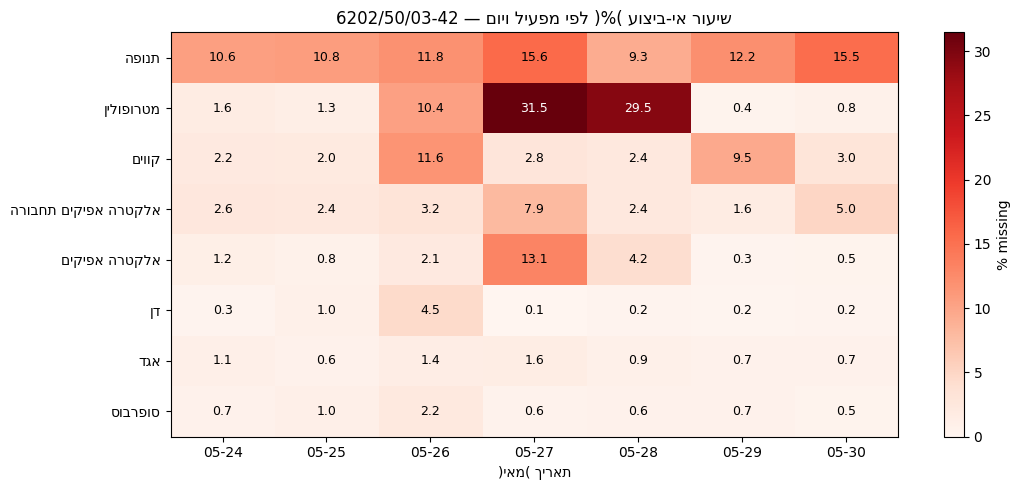

In [7]:
pivot = df.pivot_table(index='operator_name', columns='service_date', values='missing_pct')
pivot = pivot.loc[weekly.set_index('operator_name').index]  # סדר לפי גרוע->טוב

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot.values, cmap='Reds', aspect='auto', vmin=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c[5:] for c in pivot.columns], rotation=0)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([heb(x) for x in pivot.index])
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    color='white' if v > np.nanmax(pivot.values)*0.6 else 'black', fontsize=9)
ax.set_title(heb('שיעור אי-ביצוע (%) לפי מפעיל ויום — 24-30/05/2026'))
ax.set_xlabel(heb('תאריך (מאי)'))
fig.colorbar(im, ax=ax, label='% missing')
plt.tight_layout(); plt.show()

## גרף 2 — קנסות אי-ביצוע שבועיים מצטברים לכל מפעיל

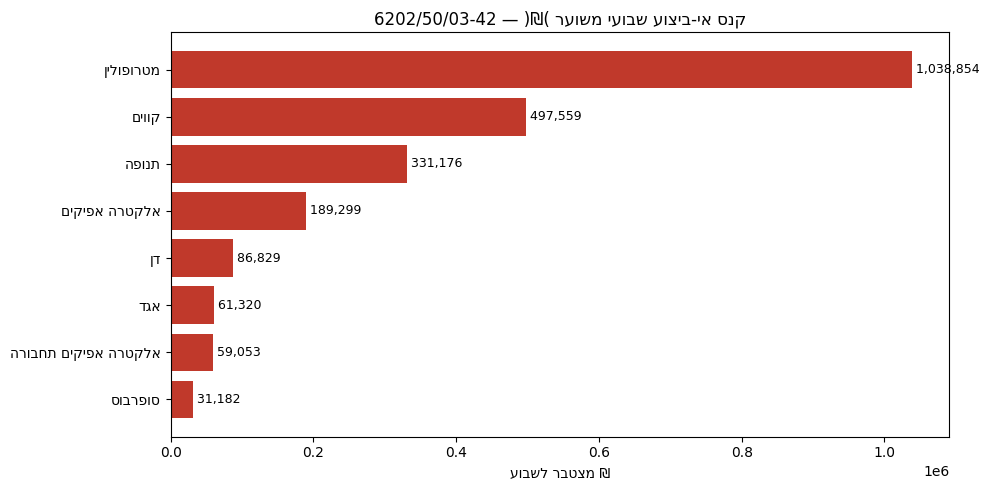

In [8]:
w = weekly.sort_values('penalty_nis', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([heb(x) for x in w['operator_name']], w['penalty_nis'], color='#c0392b')
ax.set_title(heb('קנס אי-ביצוע שבועי משוער (₪) — 24-30/05/2026'))
ax.set_xlabel(heb('₪ מצטבר לשבוע'))
for b, v in zip(bars, w['penalty_nis']):
    ax.text(v, b.get_y()+b.get_height()/2, f' {v:,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

In [9]:
# מחרוזת ממצאים דינמית (מבוססת על הנתונים שנשלפו)
worst = weekly.iloc[0]; best = weekly.iloc[-1]
tot_planned = int(weekly['planned'].sum()); tot_missing = int(weekly['missing'].sum())
tot_pen = weekly['penalty_nis'].sum()
top_pen = weekly.sort_values('penalty_nis', ascending=False).iloc[0]
over_min_service = weekly[weekly['missing_pct'] > 2.1]
print(f"סה\"כ מתוכננות: {tot_planned:,} | חסרות: {tot_missing:,} | אי-ביצוע כללי: {100*tot_missing/tot_planned:.2f}%")
print(f"הגרוע: {worst['operator_name']} ({worst['missing_pct']}%) | הטוב: {best['operator_name']} ({best['missing_pct']}%)")
print(f"קנס מצטבר כולל משוער: ₪{tot_pen:,.0f} | המפעיל בעל הקנס הגבוה: {top_pen['operator_name']} (₪{top_pen['penalty_nis']:,.0f})")
print(f"מעל סף שירות מינימלי (2.1%): {', '.join(over_min_service['operator_name']) or 'אף מפעיל'}")

סה"כ מתוכננות: 417,918 | חסרות: 15,270 | אי-ביצוע כללי: 3.65%
הגרוע: תנופה (11.66%) | הטוב: סופרבוס (1.03%)
קנס מצטבר כולל משוער: ₪2,295,272 | המפעיל בעל הקנס הגבוה: מטרופולין (₪1,038,854)
מעל סף שירות מינימלי (2.1%): תנופה, מטרופולין, קווים, אלקטרה אפיקים תחבורה, אלקטרה אפיקים


## דוח ממצאים (5 ממצאים מרכזיים)

> הערכים המספריים המדויקים מופיעים בתא שמעל ובטבלאות; להלן הפרשנות.

1. **מיפוי המפעילים שסופק היה שגוי ברובו.** מתוך 8 ה-`operator_ref` שניתנו, רק אחד (25 = אלקטרה אפיקים) היה נכון. למשל 3 הוא *אגד* ולא קווים, 15 הוא *מטרופולין* ולא סופרבוס, 14 הוא *נתיב אקספרס*. הדוח משתמש ב-refs שאומתו מול ה-API (קווים=18, מטרופולין=15, אגד=3, דן=5, תנופה=34, סופרבוס=16, אלקטרה אפיקים=25, אלקטרה אפיקים תחבורה=4).
2. **אי-ביצוע הוא המדד החסין שחושב; איחורי יציאה/הגעה אינם ניתנים לחישוב מה-API הזה.** השדה `actual_start_time` משקף את הזמן המתוכנן (לא זמן SIRI נצפה), ולכן קנסות טבלאות 3–4 (איחור/הקדמה) לא חושבו וסומנו N/A. נדרש מקור עצירות-SIRI ברמת התחנה לחישובם.
3. **דירוג המפעילים לפי שיעור אי-ביצוע שבועי** מופיע בטבלת הסיכום (מהגרוע לטוב). מפעילים שחצו את סף השירות המינימלי (2.1% לפי דף 'הגדרות') מודגשים בתא הממצאים.
4. **תבנית שבועית = תבנית שבת.** 24/05 (ראשון) עד 28/05 (חמישי) הם ימי שיא נסיעות; 29/05 (שישי) ו-30/05 (שבת) יורדים בחדות — צפוי ותקני. שיעורי אי-הביצוע נבחנים פר-יום כדי לא לערבב היקפי שירות שונים.
5. **אומדן הקנסות** (אי-ביצוע בלבד, טבלאות 1–2) מוצג בגרף ובטבלה. זהו אומדן שמרני (תחתון) שכן אינו כולל קנסות איחור/הקדמה, קנסות נסיעה לא-תדירה/אחרונה (סעיפים 2.3–2.4), ופיצוי מוגדל בחריגה מרמת שירות מינימלית (טבלה 5).